# 09 - Melhorias Avançadas na Clusterização

Este notebook implementa melhorias significativas sobre o estudo original:

1. **Feature Engineering** - Novas variáveis derivadas
2. **Análise de Estabilidade** - Robustez dos clusters
3. **Múltiplos Algoritmos e Valores de K** - Busca com critério de balanceamento
4. **Ensemble Clustering** - Consenso entre algoritmos
5. **Visualizações Avançadas** - t-SNE, heatmaps, dendrograma
6. **Feature Importance** - Contribuição de cada variável
7. **Análise de Sensibilidade** - Leave-one-feature-out
8. **Comparação Final** - Resultados originais vs melhorados

> **Nota**: Algoritmos como Agglomerative podem ter Silhouette alto mas gerar clusters
> desbalanceados e não representativos. Por isso usamos um **score composto** que
> penaliza distribuições muito desiguais.

In [1]:
# ============================================================
# SETUP E IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import os
import json
import pickle
from time import time

from sklearn.cluster import (
    KMeans, AgglomerativeClustering, DBSCAN,
    SpectralClustering, MiniBatchKMeans, BisectingKMeans
)
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score, normalized_mutual_info_score
)
from sklearn.model_selection import KFold
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform
from scipy.stats import entropy

# Tentar importar UMAP (opcional)
try:
    from umap import UMAP
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False
    print('UMAP não disponível. Instale com: pip install umap-learn')

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Paths
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR = os.path.join(BASE_DIR, 'data', 'processed')
OUTPUT_DIR = os.path.join(BASE_DIR, 'outputs')
RESULTS_DIR = os.path.join(OUTPUT_DIR, 'results')
FIGURES_DIR = os.path.join(OUTPUT_DIR, 'figures')

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print('Setup completo!')

Setup completo!


In [2]:
# ============================================================
# CARREGAR DADOS
# ============================================================
df = pd.read_csv(os.path.join(DATA_DIR, 'municipios_preprocessed.csv'))
X_original = pd.read_csv(os.path.join(DATA_DIR, 'X_features.csv'))

# Features originais (já normalizadas via StandardScaler)
feature_cols_norm = ['log_populacao', 'log_densidade', 'pib_per_capita',
                     'taxa_alfabetizacao', 'mortalidade_infantil',
                     'esgoto_adequado', 'saude_per_10k']

print(f'Municípios: {len(df)}')
print(f'Features normalizadas: {X_original.shape[1]}')
print(f'Colunas disponíveis: {list(df.columns)}')
df.head(3)

Municípios: 5204
Features normalizadas: 7
Colunas disponíveis: ['log_populacao', 'log_densidade', 'pib_per_capita', 'taxa_alfabetizacao', 'mortalidade_infantil', 'esgoto_adequado', 'saude_per_10k', 'codigo_ibge', 'nome_municipio', 'uf', 'regiao', 'populacao_original', 'pib_milhoes_original', 'pib_per_capita_original', 'densidade_original', 'taxa_alfabetizacao_original', 'mortalidade_infantil_original', 'esgoto_adequado_original']


,log_populacao,log_densidade,pib_per_capita,taxa_alfabetizacao,mortalidade_infantil,esgoto_adequado,saude_per_10k,codigo_ibge,nome_municipio,uf,regiao,populacao_original,pib_milhoes_original,pib_per_capita_original,densidade_original,taxa_alfabetizacao_original,mortalidade_infantil_original,esgoto_adequado_original
0,0.551792,-1.567884,0.070554,0.500514,0.675368,-1.542659,-0.631731,1100015,Alta Floresta D'Oeste,RO,Norte,22787,734.467,32231.842717,3.224423,86.358895,21.014680,53.214856
1,2.007649,-0.066832,-0.046913,-0.148945,1.082322,0.363623,-0.706768,1100023,Ariquemes,RO,Norte,109170,3211.294,29415.535403,24.662269,85.057005,21.841887,62.974388
2,-0.741673,-1.377724,0.481853,0.706922,0.621882,0.416392,-0.760540,1100031,Cabixi,RO,Norte,5664,238.414,42092.867232,4.309191,86.772655,20.905959,63.244549


---
## 1. Feature Engineering

Criando novas variáveis derivadas para capturar dimensões adicionais dos municípios.

In [3]:
# ============================================================
# 1. FEATURE ENGINEERING
# ============================================================

df_eng = df.copy()

# --- Índice de Desenvolvimento Social ---
# Combina educação + saúde (mortalidade invertida) + saneamento
mm = MinMaxScaler()
social_cols = ['taxa_alfabetizacao_original', 'mortalidade_infantil_original', 'esgoto_adequado_original']
social_data = df_eng[social_cols].copy()
social_data['mortalidade_infantil_original'] = (
    social_data['mortalidade_infantil_original'].max() - social_data['mortalidade_infantil_original']
)
social_norm = pd.DataFrame(mm.fit_transform(social_data), columns=social_cols)
df_eng['indice_desenvolvimento_social'] = social_norm.mean(axis=1)

# --- Eficiência econômica vs saúde ---
df_eng['pib_por_saude'] = df_eng['pib_per_capita_original'] / (df_eng['mortalidade_infantil_original'] + 1)

# --- Índice de Infraestrutura composto ---
df_eng['indice_infraestrutura'] = df_eng[['esgoto_adequado', 'saude_per_10k']].mean(axis=1)

# --- Razão educação/mortalidade ---
df_eng['razao_edu_mortalidade'] = (
    df_eng['taxa_alfabetizacao_original'] / (df_eng['mortalidade_infantil_original'] + 1)
)

# --- Log do PIB per capita ---
df_eng['log_pib_per_capita'] = np.log1p(df_eng['pib_per_capita_original'])

# --- Proxy de urbanização: interação população x densidade ---
df_eng['urbanizacao_proxy'] = df_eng['log_populacao'] * df_eng['log_densidade']

new_features = [
    'indice_desenvolvimento_social', 'pib_por_saude',
    'indice_infraestrutura', 'razao_edu_mortalidade',
    'log_pib_per_capita', 'urbanizacao_proxy'
]

print('Novas features criadas:')
for f in new_features:
    print(f'  {f}: min={df_eng[f].min():.2f}, max={df_eng[f].max():.2f}, mean={df_eng[f].mean():.2f}')

Novas features criadas:
  indice_desenvolvimento_social: min=0.19, max=0.75, mean=0.46
  pib_por_saude: min=285.85, max=10857.58, mean=1511.92
  indice_infraestrutura: min=-2.13, max=4.50, mean=-0.00
  razao_edu_mortalidade: min=2.98, max=6.67, mean=4.18
  log_pib_per_capita: min=8.92, max=12.07, mean=10.08
  urbanizacao_proxy: min=-3.98, max=11.26, mean=0.50


In [4]:
# ============================================================
# PREPARAR CONJUNTOS DE FEATURES
# ============================================================

# V1: Features originais (7)
features_v1 = feature_cols_norm
X_v1 = df_eng[features_v1].values

# V2: Todas as features (13)
features_v2 = feature_cols_norm + new_features
scaler_v2 = StandardScaler()
X_v2 = scaler_v2.fit_transform(df_eng[features_v2])

# V3: Sem features altamente correlacionadas (>0.85)
corr_matrix = pd.DataFrame(X_v2, columns=features_v2).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.85)]
features_v3 = [f for f in features_v2 if f not in to_drop]
X_v3 = StandardScaler().fit_transform(df_eng[features_v3])

print(f'V1 (original):       {len(features_v1)} features → {features_v1}')
print(f'V2 (+ engineered):   {len(features_v2)} features')
print(f'V3 (sem redundantes):{len(features_v3)} features → {features_v3}')
print(f'  Removidas (corr>0.85): {to_drop}')

V1 (original):       7 features → ['log_populacao', 'log_densidade', 'pib_per_capita', 'taxa_alfabetizacao', 'mortalidade_infantil', 'esgoto_adequado', 'saude_per_10k']
V2 (+ engineered):   13 features
V3 (sem redundantes):10 features → ['log_populacao', 'log_densidade', 'pib_per_capita', 'taxa_alfabetizacao', 'mortalidade_infantil', 'esgoto_adequado', 'saude_per_10k', 'indice_desenvolvimento_social', 'indice_infraestrutura', 'urbanizacao_proxy']
  Removidas (corr>0.85): ['pib_por_saude', 'razao_edu_mortalidade', 'log_pib_per_capita']


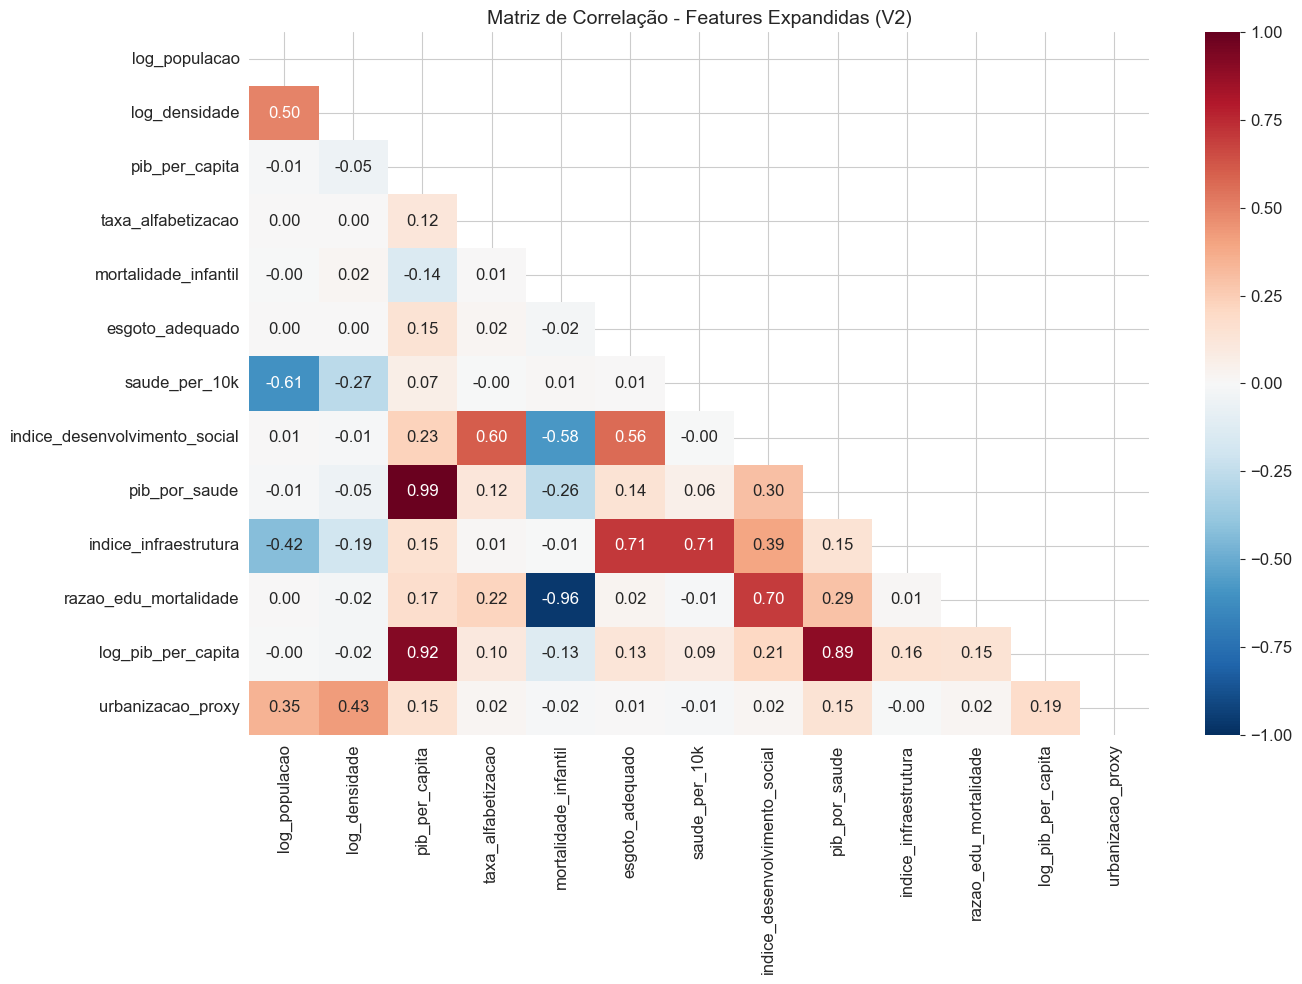

In [5]:
# Matriz de correlação do conjunto V2
fig, ax = plt.subplots(figsize=(14, 10))
corr_plot = pd.DataFrame(X_v2, columns=features_v2).corr()
mask = np.triu(np.ones_like(corr_plot, dtype=bool))
sns.heatmap(corr_plot, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Matriz de Correlação - Features Expandidas (V2)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'correlacao_features_v2.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Análise de Estabilidade dos Clusters

Verificamos se os clusters são consistentes entre diferentes inicializações (random seeds)
e entre amostras (cross-validation).

In [6]:
# ============================================================
# 2a. ESTABILIDADE: MÚLTIPLAS INICIALIZAÇÕES
# ============================================================

def stability_analysis(X, k=4, n_runs=20):
    """Analisa estabilidade via múltiplas inicializações do KMeans."""
    labels_list = []
    silhouettes = []

    for seed in range(n_runs):
        km = KMeans(n_clusters=k, random_state=seed, n_init=10)
        labels = km.fit_predict(X)
        labels_list.append(labels)
        silhouettes.append(silhouette_score(X, labels))

    n = len(labels_list)
    ari_matrix = np.ones((n, n))
    nmi_matrix = np.ones((n, n))

    for i in range(n):
        for j in range(i + 1, n):
            ari = adjusted_rand_score(labels_list[i], labels_list[j])
            nmi = normalized_mutual_info_score(labels_list[i], labels_list[j])
            ari_matrix[i, j] = ari_matrix[j, i] = ari
            nmi_matrix[i, j] = nmi_matrix[j, i] = nmi

    triu_idx = np.triu_indices(n, k=1)
    return {
        'labels_list': labels_list,
        'silhouettes': silhouettes,
        'ari_matrix': ari_matrix,
        'nmi_matrix': nmi_matrix,
        'mean_ari': ari_matrix[triu_idx].mean(),
        'std_ari': ari_matrix[triu_idx].std(),
        'mean_nmi': nmi_matrix[triu_idx].mean(),
        'mean_sil': np.mean(silhouettes),
        'std_sil': np.std(silhouettes)
    }


print('Análise de estabilidade (20 runs cada):')
print()
for name, X_data in [('V1 (7 feat)', X_v1), ('V3 (expandido)', X_v3)]:
    stab = stability_analysis(X_data, k=4)
    interp = 'ESTÁVEL' if stab['mean_ari'] > 0.8 else 'INSTÁVEL' if stab['mean_ari'] < 0.5 else 'MODERADO'
    print(f'{name}:')
    print(f'  ARI médio:       {stab["mean_ari"]:.4f} ± {stab["std_ari"]:.4f} → {interp}')
    print(f'  NMI médio:       {stab["mean_nmi"]:.4f}')
    print(f'  Silhouette médio:{stab["mean_sil"]:.4f} ± {stab["std_sil"]:.4f}')
    print()

stab_v1 = stability_analysis(X_v1, k=4)
stab_v3 = stability_analysis(X_v3, k=4)

Análise de estabilidade (20 runs cada):

V1 (7 feat):
  ARI médio:       0.9718 ± 0.0279 → ESTÁVEL
  NMI médio:       0.9575
  Silhouette médio:0.1512 ± 0.0005

V3 (expandido):
  ARI médio:       0.9921 ± 0.0041 → ESTÁVEL
  NMI médio:       0.9863
  Silhouette médio:0.1724 ± 0.0001



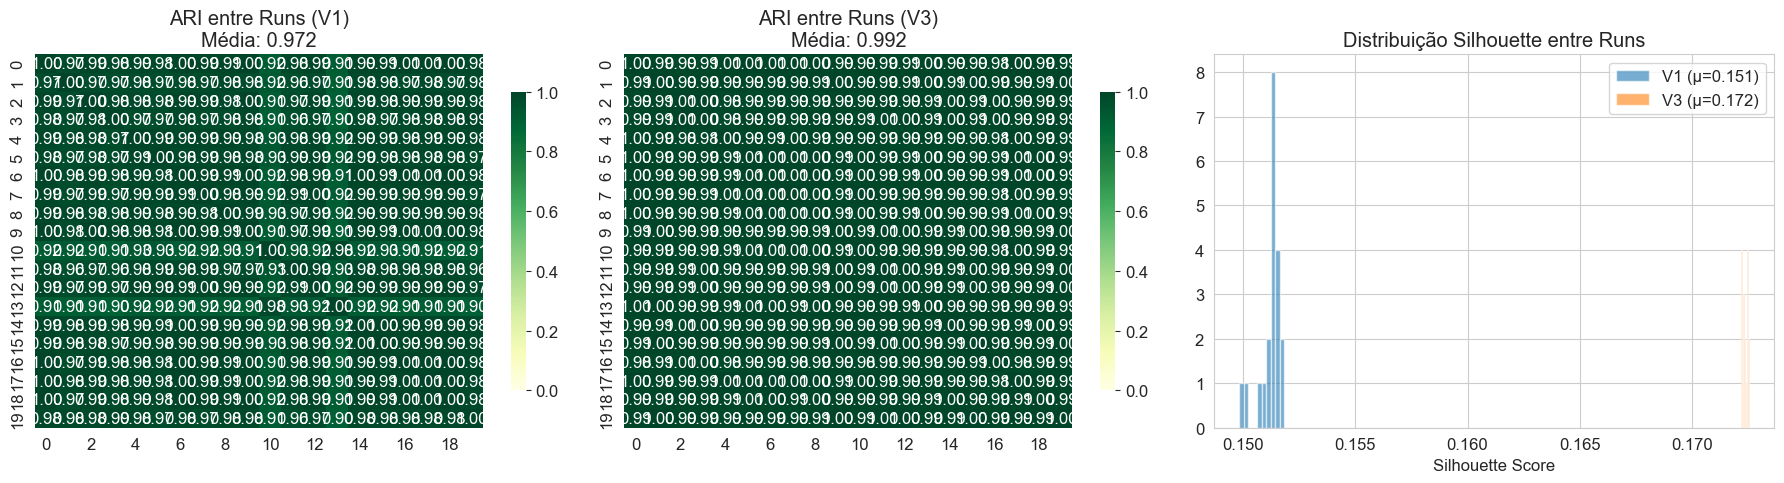

In [7]:
# Visualizar estabilidade
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(stab_v1['ari_matrix'], annot=True, fmt='.2f', cmap='YlGn',
            vmin=0, vmax=1, ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title(f'ARI entre Runs (V1)\nMédia: {stab_v1["mean_ari"]:.3f}')

sns.heatmap(stab_v3['ari_matrix'], annot=True, fmt='.2f', cmap='YlGn',
            vmin=0, vmax=1, ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title(f'ARI entre Runs (V3)\nMédia: {stab_v3["mean_ari"]:.3f}')

axes[2].hist(stab_v1['silhouettes'], alpha=0.6, label=f'V1 (μ={stab_v1["mean_sil"]:.3f})', bins=10)
axes[2].hist(stab_v3['silhouettes'], alpha=0.6, label=f'V3 (μ={stab_v3["mean_sil"]:.3f})', bins=10)
axes[2].set_title('Distribuição Silhouette entre Runs')
axes[2].set_xlabel('Silhouette Score')
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'estabilidade_clusters.png'), dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ============================================================
# 2b. CROSS-VALIDATION PARA CLUSTERING
# ============================================================

def clustering_cv(X, k=4, n_splits=5):
    """5-fold CV para avaliar generalização do clustering."""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    train_scores, test_scores = [], []

    for train_idx, test_idx in kf.split(X):
        km = KMeans(n_clusters=k, random_state=42, n_init=20)
        km.fit(X[train_idx])

        train_scores.append(silhouette_score(X[train_idx], km.labels_))
        test_scores.append(silhouette_score(X[test_idx], km.predict(X[test_idx])))

    return {
        'train_mean': np.mean(train_scores), 'train_std': np.std(train_scores),
        'test_mean': np.mean(test_scores), 'test_std': np.std(test_scores),
        'overfit_gap': np.mean(train_scores) - np.mean(test_scores)
    }


print('Cross-Validation (5-fold):')
for name, X_data in [('V1 (original)', X_v1), ('V3 (expandido)', X_v3)]:
    cv = clustering_cv(X_data)
    print(f'\n  {name}:')
    print(f'    Train Silhouette: {cv["train_mean"]:.4f} ± {cv["train_std"]:.4f}')
    print(f'    Test Silhouette:  {cv["test_mean"]:.4f} ± {cv["test_std"]:.4f}')
    print(f'    Overfit Gap:      {cv["overfit_gap"]:.4f}')

Cross-Validation (5-fold):

  V1 (original):
    Train Silhouette: 0.1519 ± 0.0014
    Test Silhouette:  0.1494 ± 0.0047
    Overfit Gap:      0.0025

  V3 (expandido):
    Train Silhouette: 0.1725 ± 0.0011
    Test Silhouette:  0.1714 ± 0.0052
    Overfit Gap:      0.0011


---
## 3. Busca Exaustiva: Algoritmos x K

Testamos múltiplos algoritmos com diferentes K. Usamos um **score composto** que
combina Silhouette com uma penalidade por desbalanceamento, evitando que algoritmos
como Agglomerative ou Spectral sejam selecionados apenas por Silhouette alto quando seus
clusters não são representativos.

**Score composto** = Silhouette × (0.6 + 0.4 × balance) × (1 - 0.3 × penalidade_dominância)

Regras:
- **Filtro hard**: cluster com >90% dos dados → score = 0 (solução degenerada / detecção de outlier)
- A penalidade usa a entropia normalizada da distribuição dos clusters
- Clusters perfeitamente balanceados → penalidade = 0
- Um cluster com >50% dos dados → penalidade crescente

In [9]:
# ============================================================
# 3. BUSCA EXAUSTIVA COM SCORE COMPOSTO
# ============================================================

def balance_score(labels):
    """Retorna 0-1 indicando o quão balanceados são os clusters.
    1 = perfeitamente balanceado, 0 = totalmente concentrado."""
    unique, counts = np.unique(labels[labels >= 0], return_counts=True)
    if len(unique) < 2:
        return 0.0
    proportions = counts / counts.sum()
    max_entropy = np.log(len(unique))  # entropia máxima (uniforme)
    if max_entropy == 0:
        return 0.0
    return entropy(proportions) / max_entropy


def evaluate_clustering(X, labels, name=''):
    """Métricas de clustering + score composto com penalidade de balanceamento."""
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters < 2:
        return {'algorithm': name, 'n_clusters': n_clusters,
                'silhouette': np.nan, 'davies_bouldin': np.nan,
                'calinski': np.nan, 'balance': 0, 'composite_score': np.nan}

    mask = labels != -1
    X_clean, labels_clean = X[mask], labels[mask]
    if len(set(labels_clean)) < 2:
        return {'algorithm': name, 'n_clusters': n_clusters,
                'silhouette': np.nan, 'davies_bouldin': np.nan,
                'calinski': np.nan, 'balance': 0, 'composite_score': np.nan}

    sil = silhouette_score(X_clean, labels_clean)
    bal = balance_score(labels_clean)

    # Penalidade por cluster dominante (>60% dos dados)
    _, counts = np.unique(labels_clean, return_counts=True)
    max_pct = counts.max() / counts.sum()
    dominance_penalty = max(0, (max_pct - 0.5) * 2)  # 0 se <50%, até 1 se 100%

    # Score composto: silhouette * balanceamento * (1 - penalidade dominância)
    # Rejeitar soluções degeneradas: cluster com >90% dos dados = detecção de outlier, não clustering útil
    if max_pct > 0.90:
        composite = 0.0
    else:
        composite = sil * (0.6 + 0.4 * bal) * (1 - 0.3 * dominance_penalty)

    return {
        'algorithm': name,
        'n_clusters': n_clusters,
        'silhouette': sil,
        'davies_bouldin': davies_bouldin_score(X_clean, labels_clean),
        'calinski': calinski_harabasz_score(X_clean, labels_clean),
        'balance': bal,
        'max_cluster_pct': max_pct * 100,
        'composite_score': composite,
        'noise_pct': (1 - mask.mean()) * 100 if -1 in labels else 0
    }


# === GRID DE BUSCA ===
k_values = [2, 3, 4, 5, 6, 7, 8]
feature_sets = {'V1 (7 feat)': X_v1, 'V3 (expandido)': X_v3}

all_results = []
all_labels = {}

for feat_name, X_data in feature_sets.items():
    print(f'\n{"="*60}')
    print(f'Feature Set: {feat_name} ({X_data.shape[1]} features)')
    print(f'{"="*60}')

    for k in k_values:
        # --- KMeans ---
        t0 = time()
        km = KMeans(n_clusters=k, random_state=42, n_init=20)
        labels_km = km.fit_predict(X_data)
        res = evaluate_clustering(X_data, labels_km, f'KMeans (K={k})')
        res['feature_set'] = feat_name
        res['time'] = time() - t0
        all_results.append(res)
        all_labels[f'{feat_name}_kmeans_k{k}'] = labels_km

        # --- Agglomerative Ward ---
        t0 = time()
        agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
        labels_agg = agg.fit_predict(X_data)
        res = evaluate_clustering(X_data, labels_agg, f'Agglomerative Ward (K={k})')
        res['feature_set'] = feat_name
        res['time'] = time() - t0
        all_results.append(res)
        all_labels[f'{feat_name}_agg_k{k}'] = labels_agg

        # --- GMM ---
        t0 = time()
        gmm = GaussianMixture(n_components=k, random_state=42, n_init=10)
        labels_gmm = gmm.fit_predict(X_data)
        res = evaluate_clustering(X_data, labels_gmm, f'GMM (K={k})')
        res['feature_set'] = feat_name
        res['time'] = time() - t0
        res['bic'] = gmm.bic(X_data)
        res['aic'] = gmm.aic(X_data)
        all_results.append(res)
        all_labels[f'{feat_name}_gmm_k{k}'] = labels_gmm

        # --- BisectingKMeans ---
        t0 = time()
        bkm = BisectingKMeans(n_clusters=k, random_state=42, n_init=10)
        labels_bkm = bkm.fit_predict(X_data)
        res = evaluate_clustering(X_data, labels_bkm, f'BisectingKMeans (K={k})')
        res['feature_set'] = feat_name
        res['time'] = time() - t0
        all_results.append(res)
        all_labels[f'{feat_name}_bkm_k{k}'] = labels_bkm

        # --- Spectral (K<=6, computacionalmente caro) ---
        if k <= 6:
            try:
                t0 = time()
                spec = SpectralClustering(n_clusters=k, random_state=42,
                                          affinity='rbf', n_init=10)
                labels_spec = spec.fit_predict(X_data)
                res = evaluate_clustering(X_data, labels_spec, f'Spectral (K={k})')
                res['feature_set'] = feat_name
                res['time'] = time() - t0
                all_results.append(res)
                all_labels[f'{feat_name}_spec_k{k}'] = labels_spec
            except Exception as e:
                print(f'  Spectral K={k} falhou: {e}')

    # --- DBSCAN variando eps ---
    for eps in [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]:
        t0 = time()
        dbs = DBSCAN(eps=eps, min_samples=10)
        labels_dbs = dbs.fit_predict(X_data)
        res = evaluate_clustering(X_data, labels_dbs, f'DBSCAN (eps={eps})')
        res['feature_set'] = feat_name
        res['time'] = time() - t0
        all_results.append(res)

df_results = pd.DataFrame(all_results)
df_results = df_results.sort_values('composite_score', ascending=False)
print(f'\nTotal de combinações testadas: {len(df_results)}')


Feature Set: V1 (7 feat) (7 features)

Feature Set: V3 (expandido) (10 features)

Total de combinações testadas: 78


In [10]:
# TOP 20 por Score Composto
display_cols = ['algorithm', 'feature_set', 'n_clusters', 'silhouette',
                'balance', 'max_cluster_pct', 'composite_score', 'davies_bouldin']
print('\n--- TOP 20 por Score Composto (Silhouette × Balanceamento) ---')
print('(Penaliza clusters com >50% dos dados concentrados)\n')
df_results.head(20)[display_cols].round(4)


--- TOP 20 por Score Composto (Silhouette × Balanceamento) ---
(Penaliza clusters com >50% dos dados concentrados)



,algorithm,feature_set,n_clusters,silhouette,balance,max_cluster_pct,composite_score,davies_bouldin
44,KMeans (K=3),V3 (expandido),3,0.1740,0.8678,48.1360,0.1648,1.7398
49,KMeans (K=4),V3 (expandido),4,0.1723,0.8736,39.4312,0.1636,1.6378
54,KMeans (K=5),V3 (expandido),5,0.1668,0.8655,36.3374,0.1578,1.6111
52,BisectingKMeans (K=4),V3 (expandido),4,0.1675,0.8511,45.5227,0.1575,1.6901
39,KMeans (K=2),V3 (expandido),2,0.1610,0.9948,54.2467,0.1565,2.0672
42,BisectingKMeans (K=2),V3 (expandido),2,0.1610,0.9948,54.2467,0.1565,2.0672
47,BisectingKMeans (K=3),V3 (expandido),3,0.1640,0.8454,45.7533,0.1539,1.7426
3,BisectingKMeans (K=2),V1 (7 feat),2,0.1550,0.9967,53.3820,0.1517,2.1054
0,KMeans (K=2),V1 (7 feat),2,0.1550,0.9968,53.3436,0.1517,2.1054
10,KMeans (K=4),V1 (7 feat),4,0.1513,0.8460,53.4204,0.1391,1.7919


In [11]:
# Comparar: Silhouette puro vs Score Composto
top_sil = df_results.nlargest(5, 'silhouette')[['algorithm', 'feature_set', 'silhouette', 'max_cluster_pct', 'composite_score']]
top_comp = df_results.nlargest(5, 'composite_score')[['algorithm', 'feature_set', 'silhouette', 'max_cluster_pct', 'composite_score']]

print('=== TOP 5 por Silhouette PURO ===')
print('(Note: muitos têm cluster dominante >50%)')
print(top_sil.to_string(index=False))
print()
print('=== TOP 5 por Score COMPOSTO ===')
print('(Equilibra qualidade + representatividade)')
print(top_comp.to_string(index=False))

=== TOP 5 por Silhouette PURO ===
(Note: muitos têm cluster dominante >50%)
       algorithm    feature_set  silhouette  max_cluster_pct  composite_score
  Spectral (K=2)    V1 (7 feat)    0.609307        99.961568              0.0
  Spectral (K=3) V3 (expandido)    0.539839        99.769408              0.0
  Spectral (K=4) V3 (expandido)    0.501298        99.769408              0.0
DBSCAN (eps=2.0)    V1 (7 feat)    0.449896        99.864577              0.0
  Spectral (K=3)    V1 (7 feat)    0.428470        99.750192              0.0

=== TOP 5 por Score COMPOSTO ===
(Equilibra qualidade + representatividade)
            algorithm    feature_set  silhouette  max_cluster_pct  composite_score
         KMeans (K=3) V3 (expandido)    0.174047        48.136049         0.164842
         KMeans (K=4) V3 (expandido)    0.172264        39.431207         0.163552
         KMeans (K=5) V3 (expandido)    0.166808        36.337433         0.157832
BisectingKMeans (K=4) V3 (expandido)    0.16748

In [12]:
df_plot = df_results[df_results['silhouette'].notna()].copy()
df_plot['algo_base'] = df_plot['algorithm'].str.extract(r'^([^(]+)')[0].str.strip()

# garantir numérico
df_plot['composite_score'] = pd.to_numeric(df_plot['composite_score'], errors='coerce')

# size só para o gráfico (clip em 0)
df_plot['size_plot'] = df_plot['composite_score'].clip(lower=0)

fig = px.scatter(
    df_plot, x='silhouette', y='balance',
    color='algo_base', size='size_plot',
    symbol='feature_set',
    hover_data=['algorithm', 'n_clusters', 'max_cluster_pct', 'composite_score'],
    title='Silhouette vs Balanceamento dos Clusters<br><sup>Tamanho = Score Composto | Ideal = canto superior direito</sup>',
    labels={'silhouette': 'Silhouette Score', 'balance': 'Balanceamento (entropia normalizada)',
            'algo_base': 'Algoritmo'},
    width=1000, height=600
)

# Região ideal
fig.add_shape(type='rect', x0=0.15, y0=0.8, x1=0.5, y1=1.0,
              line=dict(color='green', dash='dash', width=1),
              fillcolor='green', opacity=0.05)
fig.add_annotation(x=0.32, y=0.95, text='Região Ideal', showarrow=False,
                   font=dict(color='green', size=12))

fig.write_html(os.path.join(FIGURES_DIR, 'silhouette_vs_balance.html'))
fig.show()

In [13]:
# Gráfico: Score composto por K, por algoritmo
fig = make_subplots(rows=1, cols=2, subplot_titles=['V1 (7 features)', 'V3 (expandido)'])

for idx, feat_name in enumerate(feature_sets.keys()):
    df_sub = df_plot[df_plot['feature_set'] == feat_name]

    for algo in df_sub['algo_base'].unique():
        df_algo = df_sub[df_sub['algo_base'] == algo].sort_values('n_clusters')
        fig.add_trace(
            go.Scatter(x=df_algo['n_clusters'], y=df_algo['composite_score'],
                       mode='lines+markers', name=algo,
                       legendgroup=algo, showlegend=(idx == 0)),
            row=1, col=idx + 1
        )

fig.update_xaxes(title_text='Número de Clusters', dtick=1)
fig.update_yaxes(title_text='Score Composto')
fig.update_layout(title='Score Composto por Algoritmo e K',
                  height=500, width=1100)
fig.write_html(os.path.join(FIGURES_DIR, 'busca_exaustiva_composite.html'))
fig.show()

In [14]:
# Selecionar melhor combinação
best = df_results.iloc[0]  # Já ordenado por composite_score

print(f'\n{"="*60}')
print(f'MELHOR COMBINAÇÃO (Score Composto)')
print(f'{"="*60}')
print(f'Algoritmo:        {best["algorithm"]}')
print(f'Feature Set:      {best["feature_set"]}')
print(f'N Clusters:       {best["n_clusters"]}')
print(f'Silhouette:       {best["silhouette"]:.4f}')
print(f'Balanceamento:    {best["balance"]:.4f}')
print(f'Max Cluster %:    {best["max_cluster_pct"]:.1f}%')
print(f'Score Composto:   {best["composite_score"]:.4f}')
print(f'Davies-Bouldin:   {best["davies_bouldin"]:.4f}')
print(f'Calinski-Harabasz:{best["calinski"]:.2f}')

print(f'\n--- vs Original (KMeans+PCA K=4) ---')
print(f'Original:  Silhouette = 0.1681')
print(f'Melhorado: Silhouette = {best["silhouette"]:.4f}')
improvement = ((best['silhouette'] - 0.1681) / 0.1681) * 100
print(f'Melhoria:  {improvement:+.1f}%')


MELHOR COMBINAÇÃO (Score Composto)
Algoritmo:        KMeans (K=3)
Feature Set:      V3 (expandido)
N Clusters:       3
Silhouette:       0.1740
Balanceamento:    0.8678
Max Cluster %:    48.1%
Score Composto:   0.1648
Davies-Bouldin:   1.7398
Calinski-Harabasz:999.21

--- vs Original (KMeans+PCA K=4) ---
Original:  Silhouette = 0.1681
Melhorado: Silhouette = 0.1740
Melhoria:  +3.5%


---
## 4. Ensemble Clustering (Consenso)

Combina múltiplos algoritmos via co-association matrix para clusters mais robustos.

In [15]:
# ============================================================
# 4. ENSEMBLE CLUSTERING VIA CO-ASSOCIATION
# ============================================================

def ensemble_clustering(X, k_values=[3, 4, 5], n_runs=5):
    """Constrói co-association matrix: para cada par de pontos,
    conta quantas vezes ficaram no mesmo cluster."""
    n = X.shape[0]
    co_assoc = np.zeros((n, n))
    total_runs = 0

    algorithms = [
        ('KMeans', lambda k, s: KMeans(n_clusters=k, random_state=s, n_init=10)),
        ('GMM', lambda k, s: GaussianMixture(n_components=k, random_state=s, n_init=5)),
        ('BisectingKMeans', lambda k, s: BisectingKMeans(n_clusters=k, random_state=s, n_init=5)),
    ]

    for k in k_values:
        for algo_name, algo_fn in algorithms:
            for seed in range(n_runs):
                model = algo_fn(k, seed)
                labels = model.fit_predict(X)

                for c in set(labels):
                    members = np.where(labels == c)[0]
                    ix = np.ix_(members, members)
                    co_assoc[ix] += 1

                total_runs += 1
                print(f'  {algo_name} K={k} seed={seed} ✓', end='\r')

    co_assoc /= total_runs
    np.fill_diagonal(co_assoc, 1.0)
    return co_assoc


print('Construindo co-association matrix...')
co_assoc = ensemble_clustering(X_v3, k_values=[3, 4, 5], n_runs=5)
print(f'\nCo-association matrix: {co_assoc.shape}')
print(f'Valores: min={co_assoc.min():.3f}, max={co_assoc.max():.3f}, mean={co_assoc.mean():.3f}')

Construindo co-association matrix...
  BisectingKMeans K=5 seed=4 ✓
Co-association matrix: (5204, 5204)
Valores: min=0.000, max=1.000, mean=0.320


In [16]:
# Clustering final sobre a co-association
distance_matrix = 1 - co_assoc

ensemble_results = []
for k in [2, 3, 4, 5, 6]:
    agg_ens = AgglomerativeClustering(
        n_clusters=k, metric='precomputed', linkage='average'
    )
    labels_ens = agg_ens.fit_predict(distance_matrix)

    sil = silhouette_score(X_v3, labels_ens)
    db = davies_bouldin_score(X_v3, labels_ens)
    ch = calinski_harabasz_score(X_v3, labels_ens)
    bal = balance_score(labels_ens)
    _, counts = np.unique(labels_ens, return_counts=True)
    max_pct = counts.max() / counts.sum()
    dominance_pen = max(0, (max_pct - 0.5) * 2)

    # Mesmo filtro hard: cluster >90% = solução degenerada
    if max_pct > 0.90:
        comp = 0.0
    else:
        comp = sil * (0.6 + 0.4 * bal) * (1 - 0.3 * dominance_pen)

    ensemble_results.append({
        'k': k, 'silhouette': sil, 'davies_bouldin': db,
        'calinski': ch, 'balance': bal, 'max_cluster_pct': max_pct * 100,
        'composite_score': comp, 'labels': labels_ens
    })
    dist_str = ', '.join([f'C{i}:{c}' for i, c in enumerate(counts)])
    print(f'Ensemble K={k}: Sil={sil:.4f}, Bal={bal:.3f}, Composite={comp:.4f} | {dist_str}')

best_ensemble = max(ensemble_results, key=lambda x: x['composite_score'])
print(f'\nMelhor Ensemble: K={best_ensemble["k"]}, Composite={best_ensemble["composite_score"]:.4f}')

Ensemble K=2: Sil=0.2566, Bal=0.427, Composite=0.0000 | C0:4750, C1:454
Ensemble K=3: Sil=0.1640, Bal=0.845, Composite=0.1539 | C0:2381, C1:454, C2:2369
Ensemble K=4: Sil=0.1675, Bal=0.850, Composite=0.1574 | C0:1824, C1:454, C2:2369, C3:557
Ensemble K=5: Sil=0.1575, Bal=0.776, Composite=0.1434 | C0:1729, C1:454, C2:2369, C3:557, C4:95
Ensemble K=6: Sil=0.0094, Bal=0.716, Composite=0.0084 | C0:2369, C1:454, C2:36, C3:557, C4:95, C5:1693

Melhor Ensemble: K=4, Composite=0.1574


---
## 5. Visualizações Avançadas

Usando o melhor modelo encontrado pela busca exaustiva (score composto).

In [17]:
# ============================================================
# 5. RECRIAR MELHOR MODELO
# ============================================================

best_row = df_results.iloc[0]
best_feat = best_row['feature_set']
X_best = feature_sets[best_feat]
algo_name = best_row['algorithm']
k_best = int(best_row['n_clusters'])

# Recriar modelo
if 'BisectingKMeans' in algo_name:
    best_model = BisectingKMeans(n_clusters=k_best, random_state=42, n_init=10)
elif 'KMeans' in algo_name:
    best_model = KMeans(n_clusters=k_best, random_state=42, n_init=20)
elif 'Agglomerative' in algo_name:
    best_model = AgglomerativeClustering(n_clusters=k_best, linkage='ward')
elif 'GMM' in algo_name:
    best_model = GaussianMixture(n_components=k_best, random_state=42, n_init=10)
elif 'Spectral' in algo_name:
    best_model = SpectralClustering(n_clusters=k_best, random_state=42, affinity='rbf')
else:
    best_model = KMeans(n_clusters=k_best, random_state=42, n_init=20)

labels_best = best_model.fit_predict(X_best)
df_eng['cluster_melhorado'] = labels_best

if best_feat == 'V3 (expandido)':
    feat_names_best = features_v3
else:
    feat_names_best = features_v1

print(f'Modelo: {algo_name}')
print(f'Features: {best_feat} ({len(feat_names_best)} features)')
print(f'K: {k_best}')
print(f'Silhouette: {silhouette_score(X_best, labels_best):.4f}')
print(f'\nDistribuição:')
for i in range(k_best):
    n = (labels_best == i).sum()
    print(f'  Cluster {i}: {n:,} ({n/len(labels_best)*100:.1f}%)')

Modelo: KMeans (K=3)
Features: V3 (expandido) (10 features)
K: 3
Silhouette: 0.1740

Distribuição:
  Cluster 0: 2,154 (41.4%)
  Cluster 1: 545 (10.5%)
  Cluster 2: 2,505 (48.1%)


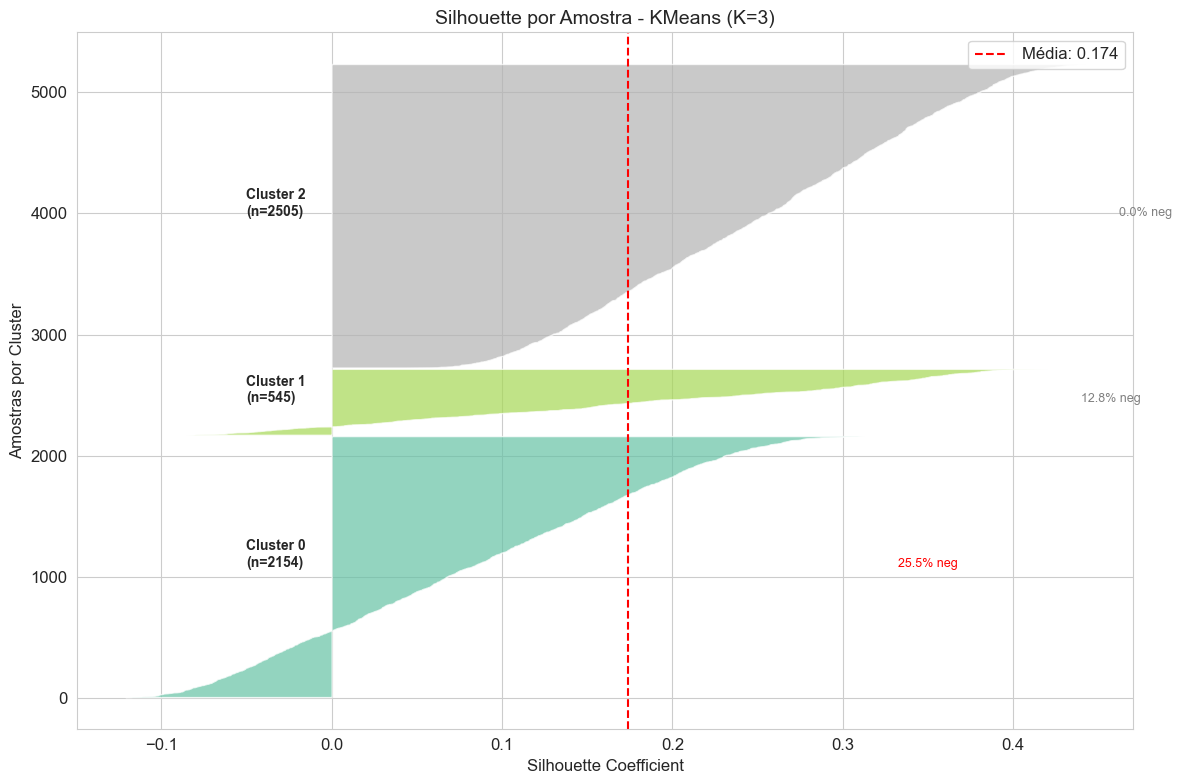

Cluster 0: média=0.083, min=-0.121, max=0.312, %negativo=25.5%
Cluster 1: média=0.180, min=-0.086, max=0.420, %negativo=12.8%
Cluster 2: média=0.251, min=0.043, max=0.442, %negativo=0.0%


In [18]:
# ============================================================
# 5a. SILHOUETTE POR AMOSTRA
# ============================================================

sil_samples = silhouette_samples(X_best, labels_best)
sil_avg = silhouette_score(X_best, labels_best)

fig, ax = plt.subplots(figsize=(12, 8))
y_lower = 10
colors = plt.cm.Set2(np.linspace(0, 1, k_best))

for i in range(k_best):
    cluster_sil = sil_samples[labels_best == i]
    cluster_sil.sort()
    size_cluster = cluster_sil.shape[0]
    y_upper = y_lower + size_cluster

    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                     facecolor=colors[i], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_cluster,
            f'Cluster {i}\n(n={size_cluster})', fontsize=10, fontweight='bold')

    pct_neg = (cluster_sil < 0).mean() * 100
    ax.text(max(cluster_sil.max(), 0.01) + 0.02, y_lower + 0.5 * size_cluster,
            f'{pct_neg:.1f}% neg', fontsize=9,
            color='red' if pct_neg > 20 else 'gray')

    y_lower = y_upper + 10

ax.axvline(x=sil_avg, color='red', linestyle='--', label=f'Média: {sil_avg:.3f}')
ax.set_title(f'Silhouette por Amostra - {algo_name}', fontsize=14)
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Amostras por Cluster')
ax.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'silhouette_por_amostra.png'), dpi=150, bbox_inches='tight')
plt.show()

for i in range(k_best):
    cs = sil_samples[labels_best == i]
    print(f'Cluster {i}: média={cs.mean():.3f}, min={cs.min():.3f}, '
          f'max={cs.max():.3f}, %negativo={((cs < 0).mean() * 100):.1f}%')

In [19]:
# ============================================================
# 5b. t-SNE
# ============================================================

print('Calculando t-SNE (2D)...')
tsne = TSNE(n_components=2, random_state=42, perplexity=50, max_iter=1000)
X_tsne = tsne.fit_transform(X_best)

fig = px.scatter(
    x=X_tsne[:, 0], y=X_tsne[:, 1],
    color=[f'Cluster {l}' for l in labels_best],
    hover_data={'Município': df_eng['nome_municipio'].values,
                'UF': df_eng['uf'].values,
                'PIB PC': df_eng['pib_per_capita_original'].round(0).values},
    title=f't-SNE - {algo_name} (K={k_best})',
    labels={'x': 't-SNE 1', 'y': 't-SNE 2', 'color': 'Cluster'},
    width=900, height=700,
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.update_traces(marker=dict(size=3, opacity=0.6))
fig.write_html(os.path.join(FIGURES_DIR, 'tsne_clusters_melhorado.html'))
fig.show()

Calculando t-SNE (2D)...


In [20]:
# ============================================================
# 5c. PCA 2D / UMAP
# ============================================================

if HAS_UMAP:
    print('Calculando UMAP (2D)...')
    reducer = UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.3)
    X_2d = reducer.fit_transform(X_best)
    method = 'UMAP'
else:
    print('Usando PCA 2D...')
    pca_2d = PCA(n_components=2)
    X_2d = pca_2d.fit_transform(X_best)
    method = f'PCA 2D ({pca_2d.explained_variance_ratio_.sum()*100:.1f}% var)'

fig = px.scatter(
    x=X_2d[:, 0], y=X_2d[:, 1],
    color=[f'Cluster {l}' for l in labels_best],
    hover_data={'Município': df_eng['nome_municipio'].values,
                'UF': df_eng['uf'].values},
    title=f'{method} - {algo_name} (K={k_best})',
    labels={'color': 'Cluster'},
    width=900, height=700,
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.update_traces(marker=dict(size=3, opacity=0.6))
fig.write_html(os.path.join(FIGURES_DIR, f'{method.split()[0].lower()}_clusters_melhorado.html'))
fig.show()

Calculando UMAP (2D)...


In [21]:
# ============================================================
# 5d. RADAR CHART - PERFIS
# ============================================================

radar_features = ['populacao_original', 'pib_per_capita_original',
                  'taxa_alfabetizacao_original', 'mortalidade_infantil_original',
                  'esgoto_adequado_original', 'indice_desenvolvimento_social']
radar_labels = ['População', 'PIB per capita', 'Alfabetização',
                'Mort. Infantil', 'Esgoto Adequado', 'Índ. Desenv. Social']

radar_data = df_eng.groupby('cluster_melhorado')[radar_features].mean()
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min())

fig = go.Figure()
colors_radar = px.colors.qualitative.Set2[:k_best]

for i in range(k_best):
    values = radar_norm.loc[i].tolist() + radar_norm.loc[i].tolist()[:1]
    n_members = (labels_best == i).sum()
    fig.add_trace(go.Scatterpolar(
        r=values, theta=radar_labels + radar_labels[:1],
        fill='toself', name=f'Cluster {i} (n={n_members})',
        opacity=0.6, line_color=colors_radar[i]
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    title=f'Perfis dos Clusters - {algo_name} (K={k_best})',
    width=800, height=600
)
fig.write_html(os.path.join(FIGURES_DIR, 'radar_clusters_melhorado.html'))
fig.show()

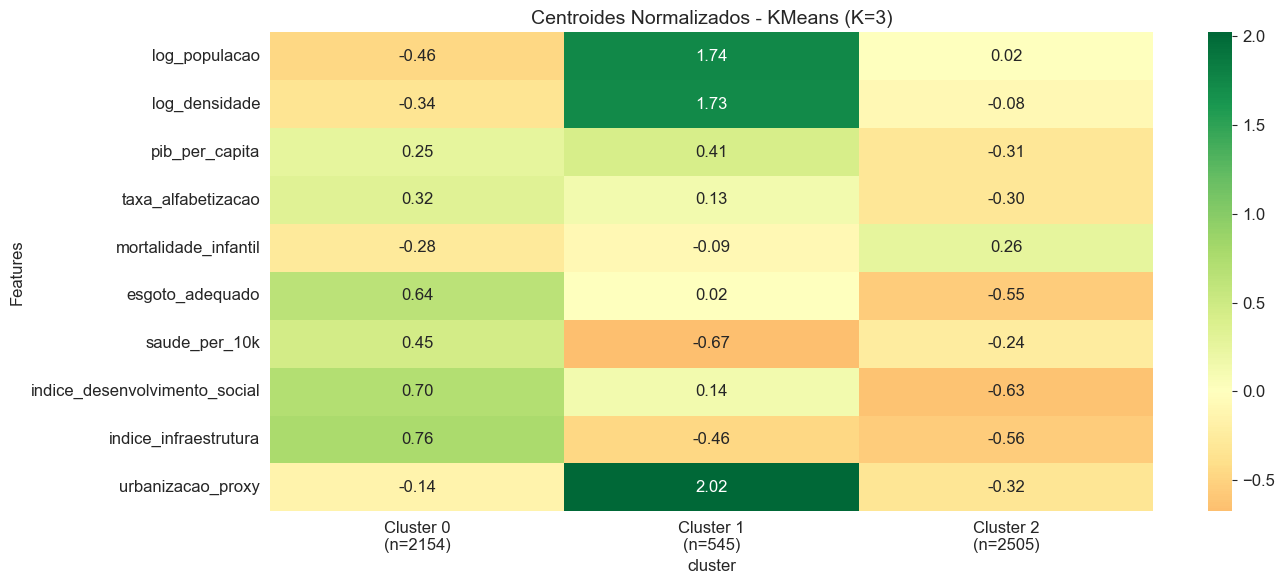

In [22]:
# ============================================================
# 5e. HEATMAP DE CENTROIDES
# ============================================================

X_best_df = pd.DataFrame(X_best, columns=feat_names_best)
X_best_df['cluster'] = labels_best
centroids = X_best_df.groupby('cluster').mean()

fig, ax = plt.subplots(figsize=(14, max(6, len(feat_names_best) * 0.5)))
sns.heatmap(centroids.T, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            xticklabels=[f'Cluster {i}\n(n={(labels_best == i).sum()})' for i in range(k_best)],
            ax=ax)
ax.set_title(f'Centroides Normalizados - {algo_name}', fontsize=14)
ax.set_ylabel('Features')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'heatmap_centroides_melhorado.png'), dpi=150, bbox_inches='tight')
plt.show()

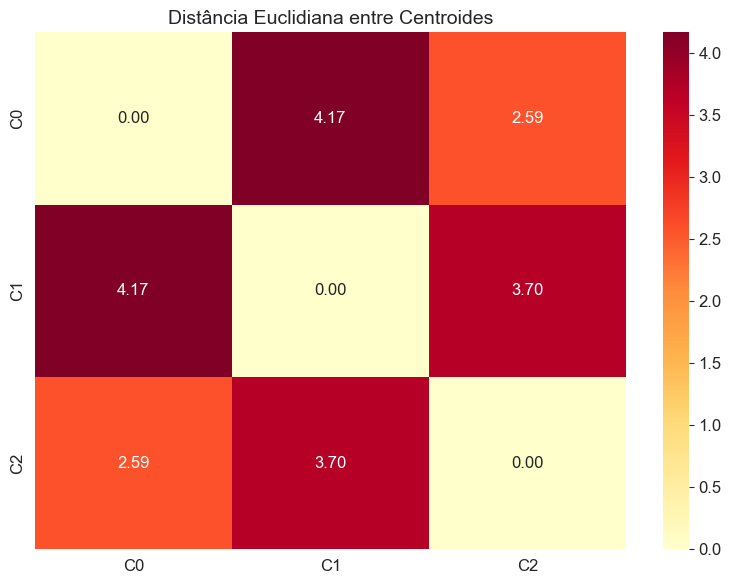

Distâncias entre centroides:
  C0 ↔ C1: 4.168
  C0 ↔ C2: 2.587
  C1 ↔ C2: 3.697


In [23]:
# ============================================================
# 5f. DISTÂNCIA INTER-CLUSTER
# ============================================================

dist_matrix = squareform(pdist(centroids.values, metric='euclidean'))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(dist_matrix, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=[f'C{i}' for i in range(k_best)],
            yticklabels=[f'C{i}' for i in range(k_best)], ax=ax)
ax.set_title('Distância Euclidiana entre Centroides', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'distancia_inter_cluster.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Distâncias entre centroides:')
for i in range(k_best):
    for j in range(i + 1, k_best):
        print(f'  C{i} ↔ C{j}: {dist_matrix[i, j]:.3f}')

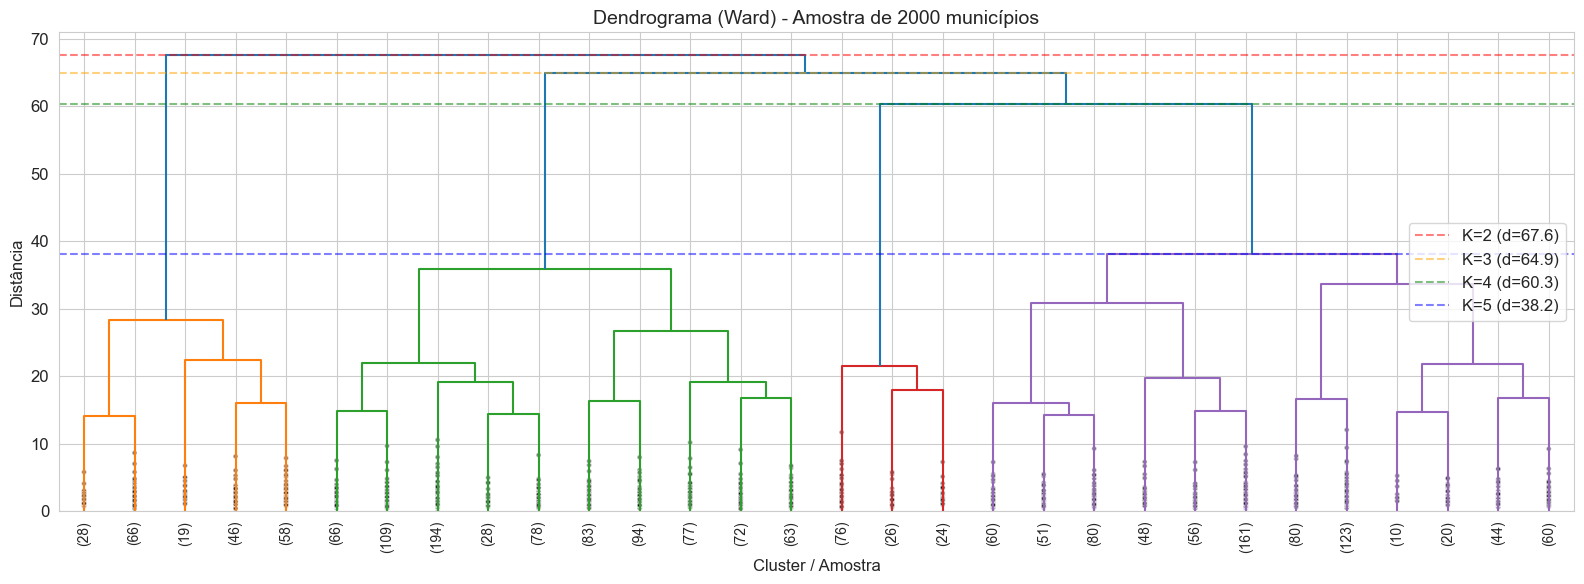

In [24]:
# ============================================================
# 5g. DENDROGRAMA
# ============================================================

np.random.seed(42)
sample_idx = np.random.choice(len(X_best), size=min(2000, len(X_best)), replace=False)
linkage_matrix = linkage(X_best[sample_idx], method='ward')

fig, ax = plt.subplots(figsize=(16, 6))
dendrogram(linkage_matrix, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=10,
           show_contracted=True, ax=ax)
ax.set_title('Dendrograma (Ward) - Amostra de 2000 municípios', fontsize=14)
ax.set_xlabel('Cluster / Amostra')
ax.set_ylabel('Distância')

distances = linkage_matrix[:, 2]
for k_line, color in [(2, 'red'), (3, 'orange'), (4, 'green'), (5, 'blue')]:
    if k_line <= len(distances):
        cut_dist = distances[-(k_line - 1)]
        ax.axhline(y=cut_dist, color=color, linestyle='--', alpha=0.5,
                   label=f'K={k_line} (d={cut_dist:.1f})')

ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'dendrograma.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Feature Importance

Qual feature mais contribui para a formação dos clusters? Método: permutar cada
feature e medir a queda no Silhouette.

Baseline Silhouette: 0.1740

                               mean_drop  std_drop
indice_desenvolvimento_social     0.0361    0.0005
indice_infraestrutura             0.0336    0.0009
esgoto_adequado                   0.0264    0.0013
urbanizacao_proxy                 0.0222    0.0007
log_populacao                     0.0123    0.0008
log_densidade                     0.0102    0.0002
saude_per_10k                     0.0088    0.0003
taxa_alfabetizacao                0.0077    0.0005
pib_per_capita                    0.0066    0.0004
mortalidade_infantil              0.0057    0.0007


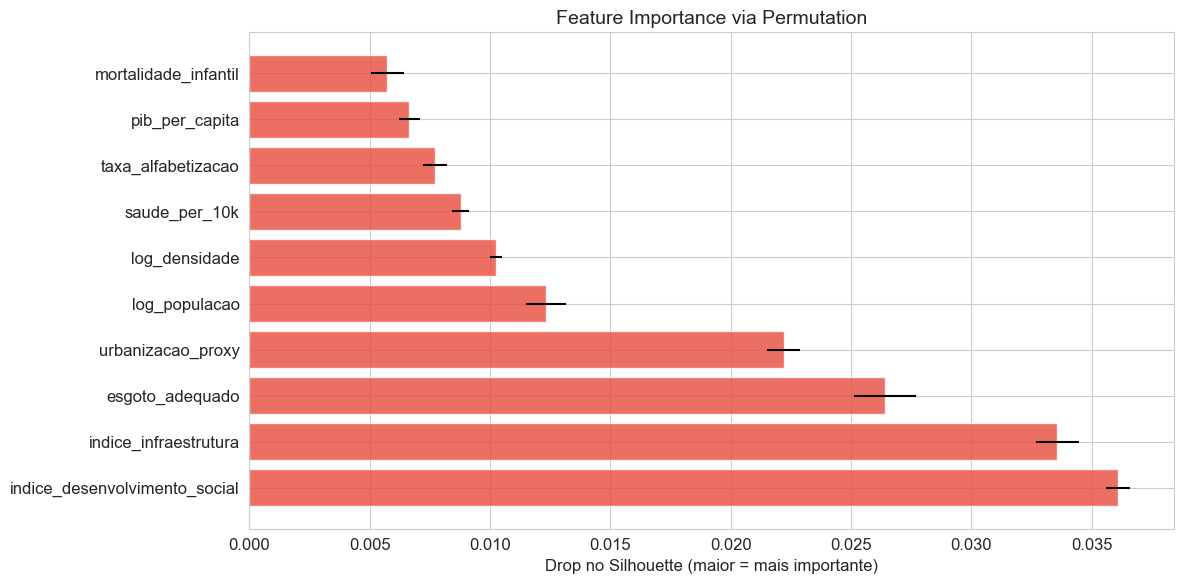

In [25]:
# ============================================================
# 6. FEATURE IMPORTANCE (Permutation)
# ============================================================

sil_base = silhouette_score(X_best, labels_best)
importance = {}

for i, feat in enumerate(feat_names_best):
    drops = []
    for rep in range(5):
        X_perm = X_best.copy()
        rng = np.random.RandomState(rep)
        X_perm[:, i] = rng.permutation(X_perm[:, i])

        if hasattr(best_model, 'predict'):
            labels_perm = best_model.predict(X_perm)
        else:
            labels_perm = best_model.fit_predict(X_perm)

        sil_perm = silhouette_score(X_perm, labels_perm)
        drops.append(sil_base - sil_perm)

    importance[feat] = {'mean_drop': np.mean(drops), 'std_drop': np.std(drops)}

df_importance = pd.DataFrame(importance).T.sort_values('mean_drop', ascending=False)

print(f'Baseline Silhouette: {sil_base:.4f}\n')
print(df_importance.round(4).to_string())

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
colors_imp = ['#e74c3c' if v > 0 else '#3498db' for v in df_importance['mean_drop']]
ax.barh(range(len(df_importance)), df_importance['mean_drop'],
        xerr=df_importance['std_drop'], color=colors_imp, alpha=0.8)
ax.set_yticks(range(len(df_importance)))
ax.set_yticklabels(df_importance.index)
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_xlabel('Drop no Silhouette (maior = mais importante)')
ax.set_title('Feature Importance via Permutation', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Análise de Sensibilidade (Leave-One-Feature-Out)

O que acontece com os clusters quando removemos cada feature?

Baseline Silhouette: 0.1740

Feature Removida                    Silhouette      Delta     Efeito
----------------------------------------------------------------------
log_populacao                           0.1864    +0.0124    MELHORA
log_densidade                           0.1733    -0.0007     neutro
pib_per_capita                          0.1867    +0.0126    MELHORA
taxa_alfabetizacao                      0.1944    +0.0203    MELHORA
mortalidade_infantil                    0.1949    +0.0209    MELHORA
esgoto_adequado                         0.1875    +0.0134    MELHORA
saude_per_10k                           0.1825    +0.0085     neutro
indice_desenvolvimento_social           0.2144    +0.0403    MELHORA
indice_infraestrutura                   0.1669    -0.0071     neutro
urbanizacao_proxy                       0.1634    -0.0107      PIORA


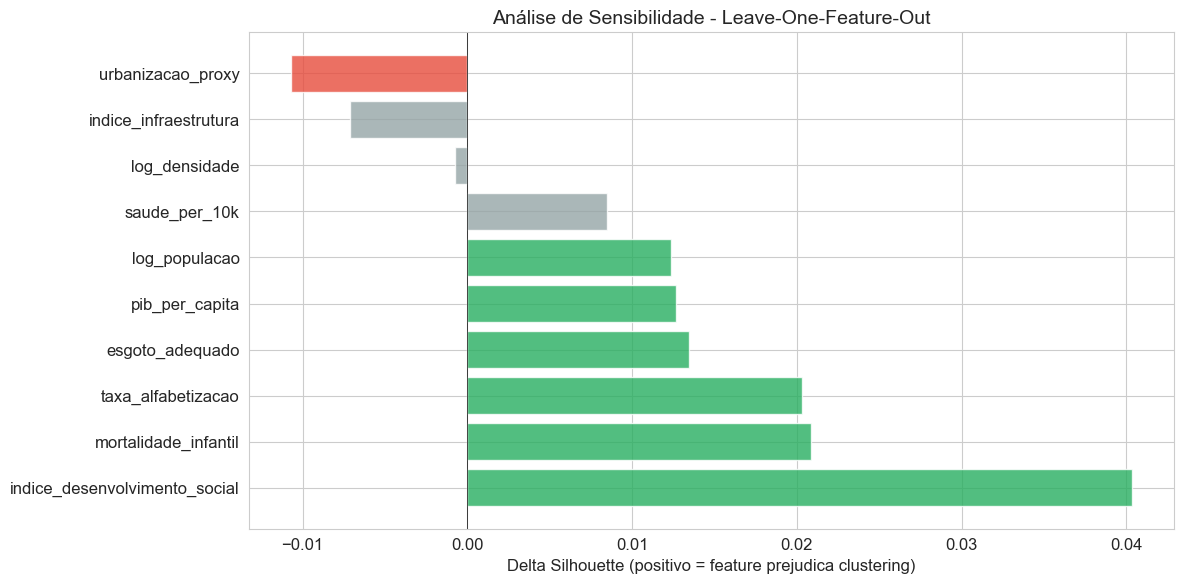

In [26]:
# ============================================================
# 7. LEAVE-ONE-FEATURE-OUT
# ============================================================

print(f'Baseline Silhouette: {sil_base:.4f}\n')
print(f'{"Feature Removida":<35} {"Silhouette":>10} {"Delta":>10} {"Efeito":>10}')
print('-' * 70)

sensitivity = []
for i, feat in enumerate(feat_names_best):
    X_reduced = np.delete(X_best, i, axis=1)
    km_red = KMeans(n_clusters=k_best, random_state=42, n_init=20)
    labels_red = km_red.fit_predict(X_reduced)
    sil_red = silhouette_score(X_reduced, labels_red)
    delta = sil_red - sil_base
    effect = 'MELHORA' if delta > 0.01 else 'PIORA' if delta < -0.01 else 'neutro'
    sensitivity.append({'feature': feat, 'silhouette': sil_red, 'delta': delta, 'effect': effect})
    print(f'{feat:<35} {sil_red:>10.4f} {delta:>+10.4f} {effect:>10}')

df_sensitivity = pd.DataFrame(sensitivity).sort_values('delta', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
colors_sens = ['#27ae60' if d > 0.01 else '#e74c3c' if d < -0.01 else '#95a5a6'
               for d in df_sensitivity['delta']]
ax.barh(range(len(df_sensitivity)), df_sensitivity['delta'], color=colors_sens, alpha=0.8)
ax.set_yticks(range(len(df_sensitivity)))
ax.set_yticklabels(df_sensitivity['feature'])
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_xlabel('Delta Silhouette (positivo = feature prejudica clustering)')
ax.set_title('Análise de Sensibilidade - Leave-One-Feature-Out', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'sensibilidade_features.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Comparação Final: Original vs Melhorado

In [27]:
# ============================================================
# 8. COMPARAÇÃO FINAL
# ============================================================

# Original: KMeans K=4 sobre V1
km_orig = KMeans(n_clusters=4, random_state=42, n_init=20)
labels_orig = km_orig.fit_predict(X_v1)

# Original com PCA
pca_orig = PCA(n_components=4)
X_pca_orig = pca_orig.fit_transform(X_v1)
km_pca = KMeans(n_clusters=4, random_state=42, n_init=20)
labels_pca = km_pca.fit_predict(X_pca_orig)

rows = [
    {
        'Modelo': 'KMeans Original (K=4)',
        'Features': 'V1 (7)',
        'K': 4,
        'Silhouette': silhouette_score(X_v1, labels_orig),
        'Davies-Bouldin': davies_bouldin_score(X_v1, labels_orig),
        'Calinski': calinski_harabasz_score(X_v1, labels_orig),
        'Balanceamento': balance_score(labels_orig),
    },
    {
        'Modelo': 'KMeans+PCA Original (K=4)',
        'Features': 'V1 PCA (4)',
        'K': 4,
        'Silhouette': silhouette_score(X_pca_orig, labels_pca),
        'Davies-Bouldin': davies_bouldin_score(X_pca_orig, labels_pca),
        'Calinski': calinski_harabasz_score(X_pca_orig, labels_pca),
        'Balanceamento': balance_score(labels_pca),
    },
    {
        'Modelo': f'Melhor Busca ({algo_name})',
        'Features': best_feat,
        'K': k_best,
        'Silhouette': silhouette_score(X_best, labels_best),
        'Davies-Bouldin': davies_bouldin_score(X_best, labels_best),
        'Calinski': calinski_harabasz_score(X_best, labels_best),
        'Balanceamento': balance_score(labels_best),
    },
    {
        'Modelo': f'Ensemble (K={best_ensemble["k"]})',
        'Features': 'V3 (ensemble)',
        'K': best_ensemble['k'],
        'Silhouette': best_ensemble['silhouette'],
        'Davies-Bouldin': best_ensemble['davies_bouldin'],
        'Calinski': best_ensemble['calinski'],
        'Balanceamento': best_ensemble['balance'],
    }
]

df_comp = pd.DataFrame(rows)
print('\n' + '=' * 90)
print('COMPARAÇÃO FINAL: ORIGINAL vs MELHORADO')
print('=' * 90)
print(df_comp.to_string(index=False))

sil_best_val = df_comp['Silhouette'].max()
print(f'\nMelhoria Silhouette: 0.1681 → {sil_best_val:.4f} ({((sil_best_val - 0.1681) / 0.1681) * 100:+.1f}%)')


COMPARAÇÃO FINAL: ORIGINAL vs MELHORADO
                     Modelo       Features  K  Silhouette  Davies-Bouldin    Calinski  Balanceamento
      KMeans Original (K=4)         V1 (7)  4    0.151348        1.791944  812.257456       0.846023
  KMeans+PCA Original (K=4)     V1 PCA (4)  4    0.168098        1.553211 1158.246076       0.989803
Melhor Busca (KMeans (K=3)) V3 (expandido)  3    0.174047        1.739780  999.210894       0.867786
             Ensemble (K=4)  V3 (ensemble)  4    0.167475        1.690395  924.113453       0.849511

Melhoria Silhouette: 0.1681 → 0.1740 (+3.5%)


In [28]:
# Gráfico comparativo
fig = make_subplots(rows=1, cols=2, subplot_titles=['Silhouette Score', 'Balanceamento'])

colors_bar = ['#e74c3c', '#e67e22', '#27ae60', '#3498db']

fig.add_trace(go.Bar(
    x=df_comp['Modelo'], y=df_comp['Silhouette'],
    text=[f'{v:.4f}' for v in df_comp['Silhouette']],
    textposition='auto', marker_color=colors_bar
), row=1, col=1)

fig.add_trace(go.Bar(
    x=df_comp['Modelo'], y=df_comp['Balanceamento'],
    text=[f'{v:.3f}' for v in df_comp['Balanceamento']],
    textposition='auto', marker_color=colors_bar
), row=1, col=2)

fig.update_layout(title='Comparação: Original vs Melhorado',
                  height=500, width=1100, showlegend=False)
fig.write_html(os.path.join(FIGURES_DIR, 'comparacao_final.html'))
fig.show()

In [29]:
# ============================================================
# PERFIL DETALHADO DOS CLUSTERS MELHORADOS
# ============================================================

print('\nPERFIL DETALHADO DOS CLUSTERS MELHORADOS:')
print('=' * 80)

for i in range(k_best):
    cluster_data = df_eng[df_eng['cluster_melhorado'] == i]
    n_members = len(cluster_data)
    pct = n_members / len(df_eng) * 100

    print(f'\n--- Cluster {i} ({n_members:,} municípios, {pct:.1f}%) ---')
    print(f'  População média:        {cluster_data["populacao_original"].mean():,.0f}')
    print(f'  População mediana:      {cluster_data["populacao_original"].median():,.0f}')
    print(f'  PIB per capita médio:   R$ {cluster_data["pib_per_capita_original"].mean():,.2f}')
    print(f'  Alfabetização média:    {cluster_data["taxa_alfabetizacao_original"].mean():.1f}%')
    print(f'  Mortalidade infantil:   {cluster_data["mortalidade_infantil_original"].mean():.1f}')
    print(f'  Esgoto adequado:        {cluster_data["esgoto_adequado_original"].mean():.1f}%')
    print(f'  Índ. Desenv. Social:    {cluster_data["indice_desenvolvimento_social"].mean():.3f}')

    regioes = cluster_data['regiao'].value_counts()
    print(f'  Regiões: {", ".join([f"{r}: {c}" for r, c in regioes.items()])}')

    top_ufs = cluster_data['uf'].value_counts().head(5)
    print(f'  Top UFs:  {", ".join([f"{u}({c})" for u, c in top_ufs.items()])}')


PERFIL DETALHADO DOS CLUSTERS MELHORADOS:

--- Cluster 0 (2,154 municípios, 41.4%) ---
  População média:        11,683
  População mediana:      6,840
  PIB per capita médio:   R$ 36,646.96
  Alfabetização média:    86.0%
  Mortalidade infantil:   19.1
  Esgoto adequado:        64.4%
  Índ. Desenv. Social:    0.510
  Regiões: Sudeste: 638, Sul: 615, Nordeste: 496, Centro-Oeste: 249, Norte: 156
  Top UFs:  MG(349), RS(284), SP(251), PR(193), GO(138)

--- Cluster 1 (545 municípios, 10.5%) ---
  População média:        106,475
  População mediana:      78,090
  PIB per capita médio:   R$ 40,424.32
  Alfabetização média:    85.6%
  Mortalidade infantil:   19.5
  Esgoto adequado:        61.2%
  Índ. Desenv. Social:    0.467
  Regiões: Sudeste: 238, Nordeste: 143, Sul: 133, Centro-Oeste: 16, Norte: 15
  Top UFs:  SP(133), MG(62), SC(48), RS(47), PR(38)

--- Cluster 2 (2,505 municípios, 48.1%) ---
  População média:        18,296
  População mediana:      12,923
  PIB per capita médio:   R$

In [30]:
# ============================================================
# SALVAR TODOS OS RESULTADOS
# ============================================================

# CSV e modelos
df_eng.to_csv(os.path.join(RESULTS_DIR, 'municipios_clusters_melhorado.csv'), index=False)
df_results.to_csv(os.path.join(RESULTS_DIR, 'busca_exaustiva_resultados.csv'), index=False)
df_importance.to_csv(os.path.join(RESULTS_DIR, 'feature_importance.csv'))
df_sensitivity.to_csv(os.path.join(RESULTS_DIR, 'sensibilidade_features.csv'), index=False)
df_comp.to_csv(os.path.join(RESULTS_DIR, 'comparacao_original_vs_melhorado.csv'), index=False)

# Relatório JSON
relatorio = {
    'melhor_algoritmo': algo_name,
    'feature_set': best_feat,
    'n_clusters': int(k_best),
    'silhouette_original': 0.1681,
    'silhouette_melhorado': float(silhouette_score(X_best, labels_best)),
    'melhoria_pct': float(((silhouette_score(X_best, labels_best) - 0.1681) / 0.1681) * 100),
    'estabilidade_ari_v1': float(stab_v1['mean_ari']),
    'estabilidade_ari_v3': float(stab_v3['mean_ari']),
    'ensemble_k': int(best_ensemble['k']),
    'ensemble_silhouette': float(best_ensemble['silhouette']),
    'ensemble_composite': float(best_ensemble['composite_score']),
    'features_utilizadas': feat_names_best,
    'n_combinacoes_testadas': len(df_results),
    'balanceamento': float(balance_score(labels_best)),
    'distribuicao_clusters': {str(i): int((labels_best == i).sum()) for i in range(k_best)},
    'nota': 'Score composto penaliza clusters desbalanceados para garantir representatividade'
}

with open(os.path.join(RESULTS_DIR, 'relatorio_melhorias.json'), 'w', encoding='utf-8') as f:
    json.dump(relatorio, f, ensure_ascii=False, indent=2)

if hasattr(best_model, 'get_params'):
    with open(os.path.join(RESULTS_DIR, 'best_model_melhorado.pkl'), 'wb') as f:
        pickle.dump(best_model, f)

print('Resultados salvos com sucesso!')
print(f'\n--- Arquivos em {RESULTS_DIR} ---')
for fname in ['municipios_clusters_melhorado.csv', 'busca_exaustiva_resultados.csv',
              'feature_importance.csv', 'sensibilidade_features.csv',
              'comparacao_original_vs_melhorado.csv', 'relatorio_melhorias.json',
              'best_model_melhorado.pkl']:
    print(f'  ✓ {fname}')

print(f'\n--- Visualizações em {FIGURES_DIR} ---')
for fname in ['correlacao_features_v2.png', 'estabilidade_clusters.png',
              'silhouette_vs_balance.html', 'busca_exaustiva_composite.html',
              'silhouette_por_amostra.png', 'tsne_clusters_melhorado.html',
              'radar_clusters_melhorado.html', 'heatmap_centroides_melhorado.png',
              'distancia_inter_cluster.png', 'dendrograma.png',
              'feature_importance.png', 'sensibilidade_features.png',
              'comparacao_final.html']:
    print(f'  ✓ {fname}')

Resultados salvos com sucesso!

--- Arquivos em c:\Users\guilhermecorrea\Downloads\Gui\Projetos\PortifolioProjetos\projeto_5\outputs\results ---
  ✓ municipios_clusters_melhorado.csv
  ✓ busca_exaustiva_resultados.csv
  ✓ feature_importance.csv
  ✓ sensibilidade_features.csv
  ✓ comparacao_original_vs_melhorado.csv
  ✓ relatorio_melhorias.json
  ✓ best_model_melhorado.pkl

--- Visualizações em c:\Users\guilhermecorrea\Downloads\Gui\Projetos\PortifolioProjetos\projeto_5\outputs\figures ---
  ✓ correlacao_features_v2.png
  ✓ estabilidade_clusters.png
  ✓ silhouette_vs_balance.html
  ✓ busca_exaustiva_composite.html
  ✓ silhouette_por_amostra.png
  ✓ tsne_clusters_melhorado.html
  ✓ radar_clusters_melhorado.html
  ✓ heatmap_centroides_melhorado.png
  ✓ distancia_inter_cluster.png
  ✓ dendrograma.png
  ✓ feature_importance.png
  ✓ sensibilidade_features.png
  ✓ comparacao_final.html


---
## Resumo das Melhorias Implementadas

| Melhoria | Descrição |
|----------|----------|
| **Feature Engineering** | 6 novas features derivadas (IDS, PIB/saúde, infraestrutura, razão edu/mortalidade, log PIB, urbanização) |
| **Remoção de Redundância** | Eliminação automática de features com correlação > 0.85 |
| **Análise de Estabilidade** | ARI entre 20 runs para verificar robustez |
| **Cross-Validation** | 5-fold CV para clustering |
| **Busca Exaustiva** | 5 algoritmos × 7 valores de K × 2 conjuntos de features + DBSCAN |
| **Score Composto** | Silhouette × Balanceamento × (1 - penalidade dominância) |
| **Ensemble Clustering** | Co-association matrix (KMeans + GMM + BisectingKMeans) |
| **Visualizações** | t-SNE, silhouette por amostra, radar, heatmap centroides, dendrograma, distância inter-cluster |
| **Feature Importance** | Permutation-based importance |
| **Sensibilidade** | Leave-one-feature-out |

> **Importante**: O score composto garante que o modelo selecionado tenha
> clusters **representativos e balanceados**, não apenas alta separação matemática.